# 03 — Робастная устойчивость без управления

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import ensure_dir, set_seed, save_dataframe, save_json, load_dataframe
from src.systems import cross_coupled_uncontrolled
from src.simulation import simulate_batch, uncertain_dynamics
from src.plots import set_plot_style, save_figure, plot_phase_trajectories, plot_residual_histogram, plot_lyapunov_contours
from src.basis import get_basis
from src.identification import fit_identified_model, predict_vector_field, rmse
from src.uncertainty import compute_residuals, residual_norms, estimate_epsilon, compute_bounding_box, bounded_disturbance
from src.lyapunov import numerical_jacobian, solve_lyapunov, evaluate_lyapunov_grid
from src.control import candidate_gains, closed_loop_jacobian

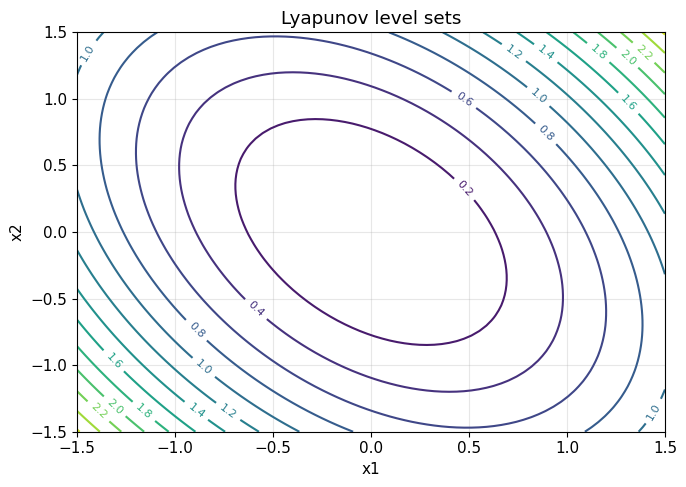

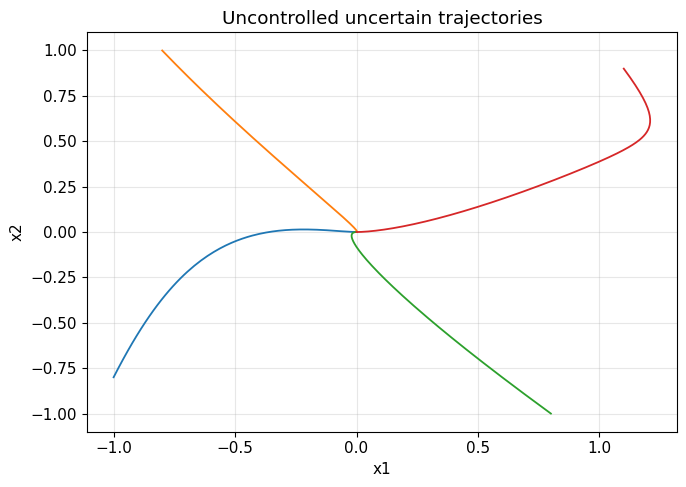

In [ ]:
set_plot_style()
df = load_dataframe('data/processed/cross_coupled_dataset.csv')
X = df[['x1','x2']].to_numpy(); Xdot = df[['xdot1','xdot2']].to_numpy()
basis_fn = get_basis('quadratic_with_constant')
res = fit_identified_model(X, Xdot, basis_fn=basis_fn, basis_name='quadratic_with_constant')

def fhat(t, x):
    return predict_vector_field(x[None, :], basis_fn, res.coefficients)[0]

A = numerical_jacobian(lambda x: fhat(0.0, x), np.zeros(2))
Q = np.eye(2)
P = solve_lyapunov(A, Q)
xx, yy, vv = evaluate_lyapunov_grid(P, (-1.5,1.5), (-1.5,1.5), points=80)
plt.figure(); plot_lyapunov_contours(xx, yy, vv); save_figure('results/figures/lyapunov_level_sets.png'); plt.show()

residual = compute_residuals(Xdot, predict_vector_field(X, basis_fn, res.coefficients))
epsilon = estimate_epsilon(residual_norms(residual), q=0.95)
unc_dyn = uncertain_dynamics(fhat, lambda t: bounded_disturbance(t, epsilon))
initials = np.array([[-1.0,-0.8],[-0.8,1.0],[0.8,-1.0],[1.1,0.9]])
t_eval = np.linspace(0, 12, 500)
traj_unc = simulate_batch(unc_dyn, initials, (0, 12), t_eval)
plt.figure(); plot_phase_trajectories(traj_unc, 'Uncontrolled uncertain trajectories'); save_figure('results/figures/uncertain_uncontrolled.png'); plt.show()

save_json({'A': A.tolist(), 'P': P.tolist(), 'epsilon_q95': float(epsilon)}, 'results/metrics/open_loop_lyapunov.json')